# 🏥 Preprocessing Notebook 2 — Clinical Dataset (1190 instances)
**Project:** Genetic Risk Integration with Lifestyle & Clinical Data for Cardiovascular Disease Stratification  
**Dataset:** Heart Disease — Combined UCI Sources (IEEE DataPort)  
**Output:** `df_clinical_train.csv`, `df_clinical_test.csv`, `df_clinical_test_raw.csv`, `clinical_scaler.pkl`, `clinical_imputer.pkl`

---

## 📌 What this notebook does (in order)
1. Loads raw data and creates a working copy (raw file is never modified)
2. Audits the dataset — documents all issues before touching anything
3. Renames columns to human-readable snake_case names
4. Replaces sentinel zeros with NaN (missing value representation)
5. Splits into train/test (80/20, stratified) — **before fitting anything**
6. Saves raw test data immediately after split — **before imputation or scaling**
7. Applies IQR clipping — **using X_train-derived bounds only** (applied to both splits)
8. Applies MICE imputation — **fit on X_train only**, transform applied to both
9. One-hot encodes multi-class categorical columns
10. Applies StandardScaler — **fit on X_train only**
11. Saves clean train/test CSVs, the fitted imputer, and the fitted scaler
12. Final validation — shape, NaN, class balance, dtype, feature integrity checks

---

## 📖 About this dataset

This file combines **5 UCI heart disease sources** into 1190 instances:

| Source | Instances |
|---|---|
| Cleveland Clinic | 303 |
| Hungarian Institute of Cardiology | 294 |
| University Hospital Zürich (Switzerland) | 123 |
| VA Medical Center, Long Beach | 200 |
| StatLog (Heart) Dataset | 270 |
| **Total** | **1190** |

**Important:** The `ca` (major vessels) and `thal` (thalassemia) columns from the original UCI files were **intentionally omitted** at source — they had >90% missingness in several contributing datasets.  

**Do NOT merge your separate Cleveland/Hungarian files with this** — 573 Cleveland rows and 95 Hungarian rows are already present here. Using both would cause severe data duplication.

---

## ⚠️ Critical notes before you run
- Always run cells **top-to-bottom** — MICE imputer and scaler must be fit before transform
- MICE is fit on **X_train only** — applying to X_test uses the same fitted imputer (no refit)
- IQR bounds are computed on **X_train only** and applied to X_test — no leakage
- Missing values in this dataset are encoded as **0** (not NaN) — we convert them in Section 5
- `df_clinical_test_raw.csv` has **12 columns** (pre-encoding); processed outputs have **19 columns** after one-hot encoding — this is expected and correct


---
## Section 1 — Imports & Configuration


In [2]:
# ── Google Drive Mount ────────────────────────────────────────────────────────
try:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=False)
    IN_COLAB = True
    print("✅ Google Drive mounted at /content/drive")
except ImportError:
    IN_COLAB = False
    print("ℹ️  Not running in Colab — skipping Drive mount. Update paths below.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Google Drive mounted at /content/drive


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

# ── Mount Drive ─────────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

# ── SINGLE SOURCE OF TRUTH ──────────────────────────────────
BASE_DIR = "/content/drive/MyDrive/CAD_DT_Final/"

RAW_DATA_DIR = BASE_DIR + "Data/Raw/"
OUTPUTS_DIR  = BASE_DIR + "Outputs/"
CLINICAL_DIR = OUTPUTS_DIR + "Clinical/"
FIGURES_DIR  = OUTPUTS_DIR + "Figures/"

# ── File Paths ──────────────────────────────────────────────
RAW_DATA_PATH = RAW_DATA_DIR + "heart_statlog_cleveland_hungary_final.csv"

TRAIN_OUT    = CLINICAL_DIR + "df_clinical_train.csv"
TEST_OUT     = CLINICAL_DIR + "df_clinical_test.csv"
TEST_RAW_OUT = CLINICAL_DIR + "df_clinical_test_raw.csv"

SCALER_OUT  = CLINICAL_DIR + "clinical_scaler.pkl"
IMPUTER_OUT = CLINICAL_DIR + "clinical_imputer.pkl"

EDA_FIG_PATH = FIGURES_DIR + "clinical_eda.png"

# ── Create ONLY required folders ────────────────────────────
os.makedirs(CLINICAL_DIR, exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)

# ── Reproducibility ─────────────────────────────────────────
RANDOM_STATE = 42
TEST_SIZE    = 0.20

print("✅ Setup complete")
print(f"   BASE_DIR        : {BASE_DIR}")
print(f"   RAW_DATA_PATH   : {RAW_DATA_PATH}")
print(f"   CLINICAL_DIR    : {CLINICAL_DIR}")
print(f"   FIGURES_DIR     : {FIGURES_DIR}")
print(f"   Random state    : {RANDOM_STATE}")
print(f"   Test size       : {TEST_SIZE*100:.0f}%")

# ── Verify dataset exists ───────────────────────────────────
assert os.path.isfile(RAW_DATA_PATH), f"❌ File not found: {RAW_DATA_PATH}"
print("   ✅ Clinical dataset found")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Setup complete
   BASE_DIR        : /content/drive/MyDrive/CAD_DT_Final/
   RAW_DATA_PATH   : /content/drive/MyDrive/CAD_DT_Final/Data/Raw/heart_statlog_cleveland_hungary_final.csv
   CLINICAL_DIR    : /content/drive/MyDrive/CAD_DT_Final/Outputs/Clinical/
   FIGURES_DIR     : /content/drive/MyDrive/CAD_DT_Final/Outputs/Figures/
   Random state    : 42
   Test size       : 20%
   ✅ Clinical dataset found


---
## Section 2 — Load Data


In [4]:
# Raw file — never modified
df_raw = pd.read_csv(RAW_DATA_PATH)

# Working copy
df = df_raw.copy()

print("=" * 55)
print("RAW DATA LOADED")
print("=" * 55)
print(f"  Shape        : {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"  Memory usage : {df.memory_usage(deep=True).sum() / 1e6:.2f} MB")
print()
print("Columns as loaded from file:")
for i, col in enumerate(df.columns, 1):
    print(f"  {i:2}. '{col}'  (dtype: {df[col].dtype})")


RAW DATA LOADED
  Shape        : 1,190 rows × 12 columns
  Memory usage : 0.11 MB

Columns as loaded from file:
   1. 'age'  (dtype: int64)
   2. 'sex'  (dtype: int64)
   3. 'chest pain type'  (dtype: int64)
   4. 'resting bp s'  (dtype: int64)
   5. 'cholesterol'  (dtype: int64)
   6. 'fasting blood sugar'  (dtype: int64)
   7. 'resting ecg'  (dtype: int64)
   8. 'max heart rate'  (dtype: int64)
   9. 'exercise angina'  (dtype: int64)
  10. 'oldpeak'  (dtype: float64)
  11. 'ST slope'  (dtype: int64)
  12. 'target'  (dtype: int64)


---
## Section 3 — Full Data Audit

We document every column's contents **before any change**.  
This is the baseline for your paper's Table 2 (dataset description).

### Known issues to look for:
- `cholesterol == 0` → missing (172 rows)
- `resting bp s == 0` → missing (1 row)  
- `ST slope == 0` → unknown/missing (1 row)
- `oldpeak` has a negative minimum (−2.6) — this is **not** an error
- Target is already binary (0/1) — no binarisation needed


In [5]:
print("=" * 55)
print("AUDIT: DATA TYPES")
print("=" * 55)
print(df.dtypes)

print()
print("=" * 55)
print("AUDIT: NULL VALUES (actual NaN)")
print("=" * 55)
actual_nulls = df.isnull().sum()
if actual_nulls.sum() == 0:
    print("  No NaN values — but zeros may encode missing values (see below)")
else:
    print(actual_nulls[actual_nulls > 0])


AUDIT: DATA TYPES
age                      int64
sex                      int64
chest pain type          int64
resting bp s             int64
cholesterol              int64
fasting blood sugar      int64
resting ecg              int64
max heart rate           int64
exercise angina          int64
oldpeak                float64
ST slope                 int64
target                   int64
dtype: object

AUDIT: NULL VALUES (actual NaN)
  No NaN values — but zeros may encode missing values (see below)


In [6]:
print("=" * 55)
print("AUDIT: ZERO VALUES (potential missing sentinels)")
print("=" * 55)
zero_check_cols = ['resting bp s', 'cholesterol', 'max heart rate', 'oldpeak', 'ST slope']
for col in zero_check_cols:
    n_zero = (df[col] == 0).sum()
    pct = n_zero / len(df) * 100
    flag = "  ⚠️  MISSING SENTINEL" if n_zero > 0 else "  ✅"
    print(f"  {col:<25}: {n_zero:>3} zeros ({pct:.1f}%) {flag}")


AUDIT: ZERO VALUES (potential missing sentinels)
  resting bp s             :   1 zeros (0.1%)   ⚠️  MISSING SENTINEL
  cholesterol              : 172 zeros (14.5%)   ⚠️  MISSING SENTINEL
  max heart rate           :   0 zeros (0.0%)   ✅
  oldpeak                  : 455 zeros (38.2%)   ⚠️  MISSING SENTINEL
  ST slope                 :   1 zeros (0.1%)   ⚠️  MISSING SENTINEL


In [7]:
print("=" * 55)
print("AUDIT: DESCRIPTIVE STATISTICS")
print("=" * 55)
print(df.describe().round(2))

print()
print("=" * 55)
print("AUDIT: CATEGORICAL COLUMN VALUE DISTRIBUTIONS")
print("=" * 55)

cat_info = {
    'sex'                : {0: 'Female', 1: 'Male'},
    'chest pain type'    : {1: 'Typical angina', 2: 'Atypical angina',
                            3: 'Non-anginal pain', 4: 'Asymptomatic'},
    'fasting blood sugar': {0: 'FBS ≤ 120 mg/dL', 1: 'FBS > 120 mg/dL'},
    'resting ecg'        : {0: 'Normal', 1: 'ST-T abnormality', 2: 'LV hypertrophy'},
    'exercise angina'    : {0: 'No', 1: 'Yes'},
    'ST slope'           : {0: 'Unknown', 1: 'Upsloping', 2: 'Flat', 3: 'Downsloping'},
}

for col, labels in cat_info.items():
    print(f"\n  {col}:")
    vc = df[col].value_counts().sort_index()
    for val, count in vc.items():
        label = labels.get(val, '?')
        print(f"    {val} ({label:<20}): {count:>4}  ({count/len(df)*100:.1f}%)")

print()
print("=" * 55)
print("AUDIT: TARGET VARIABLE")
print("=" * 55)
tc = df['target'].value_counts()
print(f"  0 = No heart disease : {tc[0]:,}  ({tc[0]/len(df)*100:.1f}%)")
print(f"  1 = Heart disease    : {tc[1]:,}  ({tc[1]/len(df)*100:.1f}%)")
print("  ✅ Target is already binary — no binarisation needed")


AUDIT: DESCRIPTIVE STATISTICS
           age      sex  chest pain type  resting bp s  cholesterol  \
count  1190.00  1190.00          1190.00       1190.00      1190.00   
mean     53.72     0.76             3.23        132.15       210.36   
std       9.36     0.42             0.94         18.37       101.42   
min      28.00     0.00             1.00          0.00         0.00   
25%      47.00     1.00             3.00        120.00       188.00   
50%      54.00     1.00             4.00        130.00       229.00   
75%      60.00     1.00             4.00        140.00       269.75   
max      77.00     1.00             4.00        200.00       603.00   

       fasting blood sugar  resting ecg  max heart rate  exercise angina  \
count              1190.00      1190.00         1190.00          1190.00   
mean                  0.21         0.70          139.73             0.39   
std                   0.41         0.87           25.52             0.49   
min                   0.00

---
## Section 4 — Column Renaming

**Why rename?**
- Original column names have spaces, abbreviations, inconsistent capitalisation
- Clean snake_case names are required for pandas operations and model pipelines
- Renaming aligns with clinical paper terminology

### Rename mapping

| Original | New Name | Notes |
|---|---|---|
| `age` | `age` | unchanged |
| `sex` | `sex` | unchanged (0=female, 1=male — consistent with 70K dataset) |
| `chest pain type` | `chest_pain_type` | spaces → underscore |
| `resting bp s` | `resting_bp` | cleaner name |
| `cholesterol` | `cholesterol` | unchanged |
| `fasting blood sugar` | `fasting_blood_sugar` | spaces → underscore |
| `resting ecg` | `resting_ecg` | spaces → underscore |
| `max heart rate` | `max_heart_rate` | spaces → underscore |
| `exercise angina` | `exercise_angina` | spaces → underscore |
| `oldpeak` | `oldpeak` | unchanged (standard clinical term) |
| `ST slope` | `st_slope` | lowercase, underscore |
| `target` | `target` | unchanged |


In [8]:
RENAME_MAP = {
    'chest pain type'    : 'chest_pain_type',
    'resting bp s'       : 'resting_bp',
    'fasting blood sugar': 'fasting_blood_sugar',
    'resting ecg'        : 'resting_ecg',
    'max heart rate'     : 'max_heart_rate',
    'exercise angina'    : 'exercise_angina',
    'ST slope'           : 'st_slope',
}

df.rename(columns=RENAME_MAP, inplace=True)

print("=" * 55)
print("COLUMN RENAMING COMPLETE")
print("=" * 55)
for old, new in RENAME_MAP.items():
    print(f"  '{old}'  →  '{new}'")
print()
print("Final column list:")
print(df.columns.tolist())


COLUMN RENAMING COMPLETE
  'chest pain type'  →  'chest_pain_type'
  'resting bp s'  →  'resting_bp'
  'fasting blood sugar'  →  'fasting_blood_sugar'
  'resting ecg'  →  'resting_ecg'
  'max heart rate'  →  'max_heart_rate'
  'exercise angina'  →  'exercise_angina'
  'ST slope'  →  'st_slope'

Final column list:
['age', 'sex', 'chest_pain_type', 'resting_bp', 'cholesterol', 'fasting_blood_sugar', 'resting_ecg', 'max_heart_rate', 'exercise_angina', 'oldpeak', 'st_slope', 'target']


---
## Section 5 — Replace Sentinel Zeros with NaN

**Why zeros are missing, not real values:**
- `cholesterol = 0 mg/dL` — biologically impossible; the body always produces cholesterol
- `resting_bp = 0 mmHg` — incompatible with life
- `st_slope = 0` — encoded as "unknown" in the original dataset, not a real category

These zeros were introduced during the multi-source merge to represent absent measurements.  
**They must be converted to NaN before imputation.** If left as zeros, MICE would treat them as real measurements and produce incorrect imputations.

**Note on `oldpeak = -2.6`:** Negative values here represent ST elevation (the inverse of depression). This is physiologically valid and is **not** replaced with NaN.


In [9]:
# Log counts before replacement
chol_zeros  = (df['cholesterol'] == 0).sum()
bp_zeros    = (df['resting_bp']  == 0).sum()
slope_zeros = (df['st_slope']    == 0).sum()

# Replace sentinel zeros with NaN
df.loc[df['cholesterol'] == 0, 'cholesterol'] = np.nan
df.loc[df['resting_bp']  == 0, 'resting_bp']  = np.nan
df.loc[df['st_slope']    == 0, 'st_slope']    = np.nan

print("=" * 55)
print("SENTINEL ZERO → NaN REPLACEMENT")
print("=" * 55)
print(f"  cholesterol == 0 replaced : {chol_zeros:>3} rows  ({chol_zeros/len(df)*100:.1f}%)")
print(f"  resting_bp  == 0 replaced : {bp_zeros:>3} rows  ({bp_zeros/len(df)*100:.1f}%)")
print(f"  st_slope    == 0 replaced : {slope_zeros:>3} rows  ({slope_zeros/len(df)*100:.1f}%)")

print()
print("  Current NaN counts per column:")
nulls = df.isnull().sum()
for col, n in nulls[nulls > 0].items():
    print(f"    {col:<22}: {n:>3}  ({n/len(df)*100:.1f}%)")

print()
print("  Columns with no missing values: ",
      [c for c in df.columns if df[c].isnull().sum() == 0 and c != 'target'])
print()
print("  ✅ oldpeak negative values are RETAINED (ST elevation — physiologically valid)")
print(f"     oldpeak min: {df['oldpeak'].min()}  max: {df['oldpeak'].max()}")


SENTINEL ZERO → NaN REPLACEMENT
  cholesterol == 0 replaced : 172 rows  (14.5%)
  resting_bp  == 0 replaced :   1 rows  (0.1%)
  st_slope    == 0 replaced :   1 rows  (0.1%)

  Current NaN counts per column:
    resting_bp            :   1  (0.1%)
    cholesterol           : 172  (14.5%)
    st_slope              :   1  (0.1%)

  Columns with no missing values:  ['age', 'sex', 'chest_pain_type', 'fasting_blood_sugar', 'resting_ecg', 'max_heart_rate', 'exercise_angina', 'oldpeak']

  ✅ oldpeak negative values are RETAINED (ST elevation — physiologically valid)
     oldpeak min: -2.6  max: 6.2


---
## Section 6 — IQR Clipping *(applied in Section 7b, after split)*

**Why clip instead of delete?**  
Unlike the 70K dataset where impossible BP values were clear data entry errors,  
outliers here (e.g. cholesterol = 603) are extreme but potentially real clinical values.  
Clipping caps them at the IQR fence rather than removing the row — we keep the observation  
but prevent extreme values from distorting model training.

**⚠️ Why IQR clipping is done AFTER the train/test split (not here):**  
If we compute IQR bounds on the full dataset, the test set values influence those bounds.  
That is a subtle form of **data leakage** — the model pipeline has "seen" the test distribution  
during preprocessing. To prevent this:
- IQR bounds are computed from **X_train only**
- The **same bounds** are then applied to X_test (no re-computation on test)

**Columns clipped:** `cholesterol`, `resting_bp`, `max_heart_rate`, `oldpeak`  
**Columns NOT clipped:** `age` (range 28–77, all valid), `st_slope` (categorical — will be imputed)

**Formula:** `[Q1 − 1.5×IQR,  Q3 + 1.5×IQR]` (Tukey fences)

> The actual clipping code is in **Section 7b** immediately after the split.


In [10]:
# IQR clipping is intentionally deferred to Section 7b (after the train/test split).
# This prevents leakage: bounds must be derived from X_train only.
# No code executes here — see Section 7b.
print("ℹ️  IQR clipping deferred to Section 7b (post-split). No action in this cell.")


ℹ️  IQR clipping deferred to Section 7b (post-split). No action in this cell.


---
## Section 7 — Train / Test Split

**⚠️ This split MUST happen before fitting the MICE imputer and StandardScaler.**  
If you fit MICE on the full dataset, information from the test set leaks into the imputed  
values of the training set — a form of data leakage that inflates evaluation metrics.

**Split parameters:**
- 80% train / 20% test  
- `stratify=target` — preserves class ratio  
- `random_state=42` — reproducibility


In [11]:
X = df.drop(columns=['target'])
y = df['target']

# NOTE: 'ca' and 'thal' are intentionally absent from this dataset (>90% missing
# in source files). Do NOT attempt to reference them — they do not exist here.

print("=" * 55)
print("PRE-SPLIT FEATURE SUMMARY")
print("=" * 55)
print(f"  Total samples  : {len(X):,}")
print(f"  Feature count  : {len(X.columns)}")
print(f"  Features       : {X.columns.tolist()}")
print()

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size    = TEST_SIZE,
    random_state = RANDOM_STATE,
    stratify     = y
)

# ── Evaluation strategy note ─────────────────────────────────────────────────
# Model evaluation will use cross-validation on the training set.
# Test set is used for FINAL reporting only — it is NOT used during training
# or hyperparameter tuning to prevent data leakage.

# ── CRITICAL: Save raw test data BEFORE imputation or scaling ────────────────
# This preserves the original (unprocessed) test observations for:
#   • interpretability / residual analysis
#   • downstream auditing
#   • integration with the genomic pipeline
df_clinical_test_raw = X_test.copy()
df_clinical_test_raw['target'] = y_test.values
df_clinical_test_raw.to_csv(TEST_RAW_OUT, index=False)
print(f"  ✅ Raw test set saved BEFORE imputation/scaling: {TEST_RAW_OUT}")
print(f"     Shape: {df_clinical_test_raw.shape}")
print()

print("=" * 55)
print("TRAIN / TEST SPLIT COMPLETE")
print("=" * 55)
print(f"  Training set   : {len(X_train):,} rows  ({len(X_train)/len(X)*100:.0f}%)")
print(f"  Test set       : {len(X_test):,} rows  ({len(X_test)/len(X)*100:.0f}%)")
print()
print(f"  Train class balance:")
print(f"    0 (No disease): {(y_train==0).sum():,}  ({(y_train==0).mean()*100:.1f}%)")
print(f"    1 (Disease)   : {(y_train==1).sum():,}  ({(y_train==1).mean()*100:.1f}%)")
print()
print(f"  Test class balance:")
print(f"    0 (No disease): {(y_test==0).sum():,}  ({(y_test==0).mean()*100:.1f}%)")
print(f"    1 (Disease)   : {(y_test==1).sum():,}  ({(y_test==1).mean()*100:.1f}%)")
print()
print("  ✅ Stratification preserved class ratio in both splits")

# Log missing value counts in train/test before imputation
print()
print("  Missing values in X_train (to be imputed):")
train_nulls = X_train.isnull().sum()
for col, n in train_nulls[train_nulls > 0].items():
    print(f"    {col:<22}: {n}")
print()
print("  Missing values in X_test (to be imputed using train-fitted imputer):")
test_nulls = X_test.isnull().sum()
for col, n in test_nulls[test_nulls > 0].items():
    print(f"    {col:<22}: {n}")


PRE-SPLIT FEATURE SUMMARY
  Total samples  : 1,190
  Feature count  : 11
  Features       : ['age', 'sex', 'chest_pain_type', 'resting_bp', 'cholesterol', 'fasting_blood_sugar', 'resting_ecg', 'max_heart_rate', 'exercise_angina', 'oldpeak', 'st_slope']

  ✅ Raw test set saved BEFORE imputation/scaling: /content/drive/MyDrive/CAD_DT_Final/Outputs/Clinical/df_clinical_test_raw.csv
     Shape: (238, 12)

TRAIN / TEST SPLIT COMPLETE
  Training set   : 952 rows  (80%)
  Test set       : 238 rows  (20%)

  Train class balance:
    0 (No disease): 449  (47.2%)
    1 (Disease)   : 503  (52.8%)

  Test class balance:
    0 (No disease): 112  (47.1%)
    1 (Disease)   : 126  (52.9%)

  ✅ Stratification preserved class ratio in both splits

  Missing values in X_train (to be imputed):
    resting_bp            : 1
    cholesterol           : 129
    st_slope              : 1

  Missing values in X_test (to be imputed using train-fitted imputer):
    cholesterol           : 43


In [12]:
# ── Section 7b — IQR Clipping (AFTER split, on X_train bounds only) ──────────
# FIX: IQR bounds computed from X_train ONLY to prevent leakage from test set.
# The same bounds are then applied to X_test.

CLIP_COLS = ['cholesterol', 'resting_bp', 'max_heart_rate', 'oldpeak']

print("=" * 55)
print("IQR CLIPPING — TRAIN-DERIVED BOUNDS (applied to both splits)")
print("=" * 55)

iqr_bounds = {}
for col in CLIP_COLS:
    series = X_train[col].dropna()
    Q1  = series.quantile(0.25)
    Q3  = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    iqr_bounds[col] = (lower, upper)

    n_clipped_lo = (X_train[col].dropna() < lower).sum()
    n_clipped_hi = (X_train[col].dropna() > upper).sum()

    X_train[col] = X_train[col].clip(lower=lower, upper=upper)
    X_test[col]  = X_test[col].clip(lower=lower, upper=upper)  # same bounds, no leakage

    print(f"  {col}:")
    print(f"    Q1={Q1:.1f}  Q3={Q3:.1f}  IQR={IQR:.1f}")
    print(f"    Fence (from X_train): [{lower:.1f}, {upper:.1f}]")
    print(f"    X_train clipped low  : {n_clipped_lo}")
    print(f"    X_train clipped high : {n_clipped_hi}")
    print(f"    New range X_train    : [{X_train[col].min():.1f}, {X_train[col].max():.1f}]")
    print(f"    New range X_test     : [{X_test[col].min():.1f}, {X_test[col].max():.1f}]")
    print()


IQR CLIPPING — TRAIN-DERIVED BOUNDS (applied to both splits)
  cholesterol:
    Q1=211.0  Q3=275.0  IQR=64.0
    Fence (from X_train): [115.0, 371.0]
    X_train clipped low  : 5
    X_train clipped high : 21
    New range X_train    : [115.0, 371.0]
    New range X_test     : [126.0, 371.0]

  resting_bp:
    Q1=120.0  Q3=140.0  IQR=20.0
    Fence (from X_train): [90.0, 170.0]
    X_train clipped low  : 0
    X_train clipped high : 31
    New range X_train    : [92.0, 170.0]
    New range X_test     : [90.0, 170.0]

  max_heart_rate:
    Q1=121.0  Q3=160.0  IQR=39.0
    Fence (from X_train): [62.5, 218.5]
    X_train clipped low  : 1
    X_train clipped high : 0
    New range X_train    : [62.5, 202.0]
    New range X_test     : [69.0, 194.0]

  oldpeak:
    Q1=0.0  Q3=1.6  IQR=1.6
    Fence (from X_train): [-2.4, 4.0]
    X_train clipped low  : 0
    X_train clipped high : 8
    New range X_train    : [-2.0, 4.0]
    New range X_test     : [-2.4, 4.0]



---
## Section 8 — MICE Imputation (fit on train only)

**Why MICE (Multiple Imputation by Chained Equations)?**  
- MICE estimates each missing value using a regression model trained on all other features  
- It preserves the relationships between variables (e.g. cholesterol and age are correlated)  
- Outperforms simple mean/median imputation, especially for clinical data  
- With only 1190 rows, the computational cost is trivial  

**Implementation:** `sklearn.impute.IterativeImputer`  
- `max_iter=10` — number of imputation cycles (10 is standard)  
- `random_state=42` — reproducibility  

**MICE is applied only to continuous columns:**  
`cholesterol`, `resting_bp`, `st_slope` (treated as continuous during imputation, rounded after)

**Why not impute categorical columns?**  
`chest_pain_type`, `resting_ecg`, `exercise_angina`, `fasting_blood_sugar`, `sex` have no missing values.

**⚠️ Key rule:** Fit on X_train. Transform X_train. Transform X_test with the same fitted imputer.


In [13]:
# Columns with missing values — only these need imputation
IMPUTE_COLS = ['cholesterol', 'resting_bp', 'st_slope']

# Confirm these are the only columns with missing values
all_missing = [c for c in X_train.columns if X_train[c].isnull().any()]
assert set(all_missing) == set(IMPUTE_COLS), f"Unexpected missing cols: {all_missing}"
print(f"  Columns to impute: {IMPUTE_COLS}")
print()

# ── Fit MICE on training data ONLY ───────────────────────────────────────────
print("  Fitting MICE imputer on X_train (this may take a moment)...")

imputer = IterativeImputer(
    max_iter     = 10,
    random_state = RANDOM_STATE,
    verbose      = 0
)

# Fit on X_train only, then transform
X_train_imputed_arr = imputer.fit_transform(X_train)
X_train = pd.DataFrame(X_train_imputed_arr, columns=X_train.columns, index=X_train.index)

# SAFETY: imputer is NOT refit on test — transform only
# Assertion: imputer.n_iter_ is set (fit complete) and we only call .transform below
assert hasattr(imputer, 'n_iter_'), "Imputer was not fitted on X_train!"
X_test_imputed_arr = imputer.transform(X_test)   # transform only — no refit
X_test = pd.DataFrame(X_test_imputed_arr, columns=X_test.columns, index=X_test.index)

print("  ✅ MICE imputation complete")
print(f"     Imputer fitted on X_train ({imputer.n_iter_} iterations)")
print("     X_test transformed with same fitted imputer — no refit on test data")
print()

# Round columns that should be integers after imputation
for col in ['cholesterol', 'resting_bp', 'st_slope']:
    X_train[col] = X_train[col].round().astype(int)
    X_test[col]  = X_test[col].round().astype(int)

print("=" * 55)
print("POST-IMPUTATION CHECKS")
print("=" * 55)
print(f"  NaN in X_train: {X_train.isnull().sum().sum()}")
print(f"  NaN in X_test : {X_test.isnull().sum().sum()}")
assert X_train.isnull().sum().sum() == 0, "NaN remains in X_train after imputation!"
assert X_test.isnull().sum().sum() == 0,  "NaN remains in X_test after imputation!"
print("  ✅ No missing values remain")

print()
print("  Imputed column stats (X_train):")
for col in IMPUTE_COLS:
    print(f"    {col:<22}: min={X_train[col].min():.1f}  max={X_train[col].max():.1f}  mean={X_train[col].mean():.1f}")

print()
print("  st_slope value distribution after imputation (X_train):")
print(f"    {X_train['st_slope'].value_counts().sort_index().to_dict()}")

# Save imputer
with open(IMPUTER_OUT, 'wb') as f:
    pickle.dump(imputer, f)
print()
print(f"  ✅ Imputer saved to: {IMPUTER_OUT}")


  Columns to impute: ['cholesterol', 'resting_bp', 'st_slope']

  Fitting MICE imputer on X_train (this may take a moment)...
  ✅ MICE imputation complete
     Imputer fitted on X_train (2 iterations)
     X_test transformed with same fitted imputer — no refit on test data

POST-IMPUTATION CHECKS
  NaN in X_train: 0
  NaN in X_test : 0
  ✅ No missing values remain

  Imputed column stats (X_train):
    cholesterol           : min=115.0  max=371.0  mean=244.2
    resting_bp            : min=92.0  max=170.0  mean=132.1
    st_slope              : min=1.0  max=3.0  mean=1.6

  st_slope value distribution after imputation (X_train):
    {1: 417, 2: 469, 3: 66}

  ✅ Imputer saved to: /content/drive/MyDrive/CAD_DT_Final/Outputs/Clinical/clinical_imputer.pkl


---
## Section 9 — One-Hot Encoding

**Columns one-hot encoded:**

| Column | Values | Reason for one-hot |
|---|---|---|
| `chest_pain_type` | 1, 2, 3, 4 | Nominal — no meaningful order |
| `resting_ecg` | 0, 1, 2 | Nominal — three distinct conditions |
| `st_slope` | 1, 2, 3 | Nominal — slope directions, no linear order |

**Columns kept as binary (not one-hot encoded):**

| Column | Values | Reason |
|---|---|---|
| `sex` | 0, 1 | Already binary |
| `fasting_blood_sugar` | 0, 1 | Already binary |
| `exercise_angina` | 0, 1 | Already binary |

**Important:** Encoding is applied to **both** X_train and X_test using the same `pd.get_dummies` call.  
To guarantee identical columns after encoding, we use `reindex` to align test columns to train.


In [14]:
ENCODE_COLS = ['chest_pain_type', 'resting_ecg', 'st_slope']
cols_before = X_train.columns.tolist()

# Encode training set
X_train = pd.get_dummies(X_train, columns=ENCODE_COLS, drop_first=False)
# Encode test set
X_test  = pd.get_dummies(X_test,  columns=ENCODE_COLS, drop_first=False)

# Convert boolean dummies to int
for col in X_train.columns:
    if X_train[col].dtype == bool:
        X_train[col] = X_train[col].astype(int)
for col in X_test.columns:
    if X_test[col].dtype == bool:
        X_test[col] = X_test[col].astype(int)

# Align test columns to train (handles any category present in train but not test)
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

print("=" * 55)
print("ONE-HOT ENCODING")
print("=" * 55)
new_cols = [c for c in X_train.columns if c not in cols_before]
print(f"  Columns before encoding : {len(cols_before)}")
print(f"  Columns after encoding  : {len(X_train.columns)}")
print()
print("  New dummy columns created:")
for c in new_cols:
    print(f"    + {c}  "
          f"(train: {X_train[c].sum()} ones | test: {X_test[c].sum()} ones)")

print()
print("  X_train and X_test column alignment: ", end="")
assert list(X_train.columns) == list(X_test.columns), "Column mismatch!"
print("✅ Identical")


ONE-HOT ENCODING
  Columns before encoding : 11
  Columns after encoding  : 18

  New dummy columns created:
    + chest_pain_type_1.0  (train: 55 ones | test: 11 ones)
    + chest_pain_type_2.0  (train: 171 ones | test: 45 ones)
    + chest_pain_type_3.0  (train: 232 ones | test: 51 ones)
    + chest_pain_type_4.0  (train: 494 ones | test: 131 ones)
    + resting_ecg_0.0  (train: 541 ones | test: 143 ones)
    + resting_ecg_1.0  (train: 148 ones | test: 33 ones)
    + resting_ecg_2.0  (train: 263 ones | test: 62 ones)
    + st_slope_1  (train: 417 ones | test: 110 ones)
    + st_slope_2  (train: 469 ones | test: 113 ones)
    + st_slope_3  (train: 66 ones | test: 15 ones)

  X_train and X_test column alignment: ✅ Identical


---
## Section 10 — StandardScaler (fit on train only)

**Columns scaled:** `age`, `resting_bp`, `cholesterol`, `max_heart_rate`, `oldpeak`  
**Columns NOT scaled:** all binary and one-hot encoded columns (already 0/1)

Same principle as the lifestyle notebook — scaler fit only on training data.


In [15]:
SCALE_COLS = ['age', 'resting_bp', 'cholesterol', 'max_heart_rate', 'oldpeak']

# Confirm columns exist
for col in SCALE_COLS:
    assert col in X_train.columns, f"Column {col} not found!"

# ── Fit on train, transform both ─────────────────────────────────────────────
scaler = StandardScaler()
scaler.fit(X_train[SCALE_COLS])

X_train = X_train.copy()
X_test  = X_test.copy()
X_train[SCALE_COLS] = scaler.transform(X_train[SCALE_COLS])
X_test[SCALE_COLS]  = scaler.transform(X_test[SCALE_COLS])

print("=" * 55)
print("STANDARD SCALER APPLIED")
print("=" * 55)
print("  Column          | Train mean (learned) | Train std (learned)")
print("  " + "-"*55)
for col, mean, std in zip(SCALE_COLS, scaler.mean_, scaler.scale_):
    print(f"  {col:<22}: mean={mean:>8.3f}    std={std:>6.3f}")

print()
print("  Post-scaling stats on X_train (should be ~mean=0, std=1):")
print(X_train[SCALE_COLS].describe().loc[['mean','std']].round(3))

print()
print("  Columns NOT scaled:")
unscaled = [c for c in X_train.columns if c not in SCALE_COLS]
print(f"    {unscaled}")

with open(SCALER_OUT, 'wb') as f:
    pickle.dump(scaler, f)
print()
print(f"  ✅ Scaler saved to: {SCALER_OUT}")


STANDARD SCALER APPLIED
  Column          | Train mean (learned) | Train std (learned)
  -------------------------------------------------------
  age                   : mean=  53.891    std= 9.404
  resting_bp            : mean= 132.088    std=16.967
  cholesterol           : mean= 244.237    std=46.356
  max_heart_rate        : mean= 139.806    std=25.417
  oldpeak               : mean=   0.941    std= 1.058

  Post-scaling stats on X_train (should be ~mean=0, std=1):
        age  resting_bp  cholesterol  max_heart_rate  oldpeak
mean  0.000      -0.000        0.000          -0.000   -0.000
std   1.001       1.001        1.001           1.001    1.001

  Columns NOT scaled:
    ['sex', 'fasting_blood_sugar', 'exercise_angina', 'chest_pain_type_1.0', 'chest_pain_type_2.0', 'chest_pain_type_3.0', 'chest_pain_type_4.0', 'resting_ecg_0.0', 'resting_ecg_1.0', 'resting_ecg_2.0', 'st_slope_1', 'st_slope_2', 'st_slope_3']

  ✅ Scaler saved to: /content/drive/MyDrive/CAD_DT_Final/Outputs/Clin

---
## Section 11 — Final Validation & Save Outputs


In [16]:
# ── Reconstruct full output DataFrames ───────────────────────────────────────
df_train_out = X_train.copy()
df_train_out['target'] = y_train.values.astype(int)   # ensure int dtype

df_test_out = X_test.copy()
df_test_out['target'] = y_test.values.astype(int)     # ensure int dtype

# ── Save outputs ─────────────────────────────────────────────────────────────
df_train_out.to_csv(TRAIN_OUT, index=False)
df_test_out.to_csv(TEST_OUT,   index=False)

print("=" * 55)
print("OUTPUTS SAVED")
print("=" * 55)
print(f"  ✅ {TRAIN_OUT}")
print(f"       {df_train_out.shape[0]:,} rows × {df_train_out.shape[1]} cols")
print(f"  ✅ {TEST_OUT}")
print(f"       {df_test_out.shape[0]:,} rows × {df_test_out.shape[1]} cols")
print(f"  ✅ {TEST_RAW_OUT}")
print(f"       {df_clinical_test_raw.shape[0]:,} rows × {df_clinical_test_raw.shape[1]} cols (pre-encoding — {df_clinical_test_raw.shape[1]} cols is correct)")
print(f"  ✅ {IMPUTER_OUT}")
print(f"  ✅ {SCALER_OUT}")
print()
print("=" * 55)
print("PREPROCESSING COMPLETE — CLINICAL DATASET")
print("=" * 55)
print(f"  Feature columns (processed) : {[c for c in df_train_out.columns if c != 'target']}")


OUTPUTS SAVED
  ✅ /content/drive/MyDrive/CAD_DT_Final/Outputs/Clinical/df_clinical_train.csv
       952 rows × 19 cols
  ✅ /content/drive/MyDrive/CAD_DT_Final/Outputs/Clinical/df_clinical_test.csv
       238 rows × 19 cols
  ✅ /content/drive/MyDrive/CAD_DT_Final/Outputs/Clinical/df_clinical_test_raw.csv
       238 rows × 12 cols (pre-encoding — 12 cols is correct)
  ✅ /content/drive/MyDrive/CAD_DT_Final/Outputs/Clinical/clinical_imputer.pkl
  ✅ /content/drive/MyDrive/CAD_DT_Final/Outputs/Clinical/clinical_scaler.pkl

PREPROCESSING COMPLETE — CLINICAL DATASET
  Feature columns (processed) : ['age', 'sex', 'resting_bp', 'cholesterol', 'fasting_blood_sugar', 'max_heart_rate', 'exercise_angina', 'oldpeak', 'chest_pain_type_1.0', 'chest_pain_type_2.0', 'chest_pain_type_3.0', 'chest_pain_type_4.0', 'resting_ecg_0.0', 'resting_ecg_1.0', 'resting_ecg_2.0', 'st_slope_1', 'st_slope_2', 'st_slope_3']


---
## Section 12 — Quick EDA Plots (Optional)


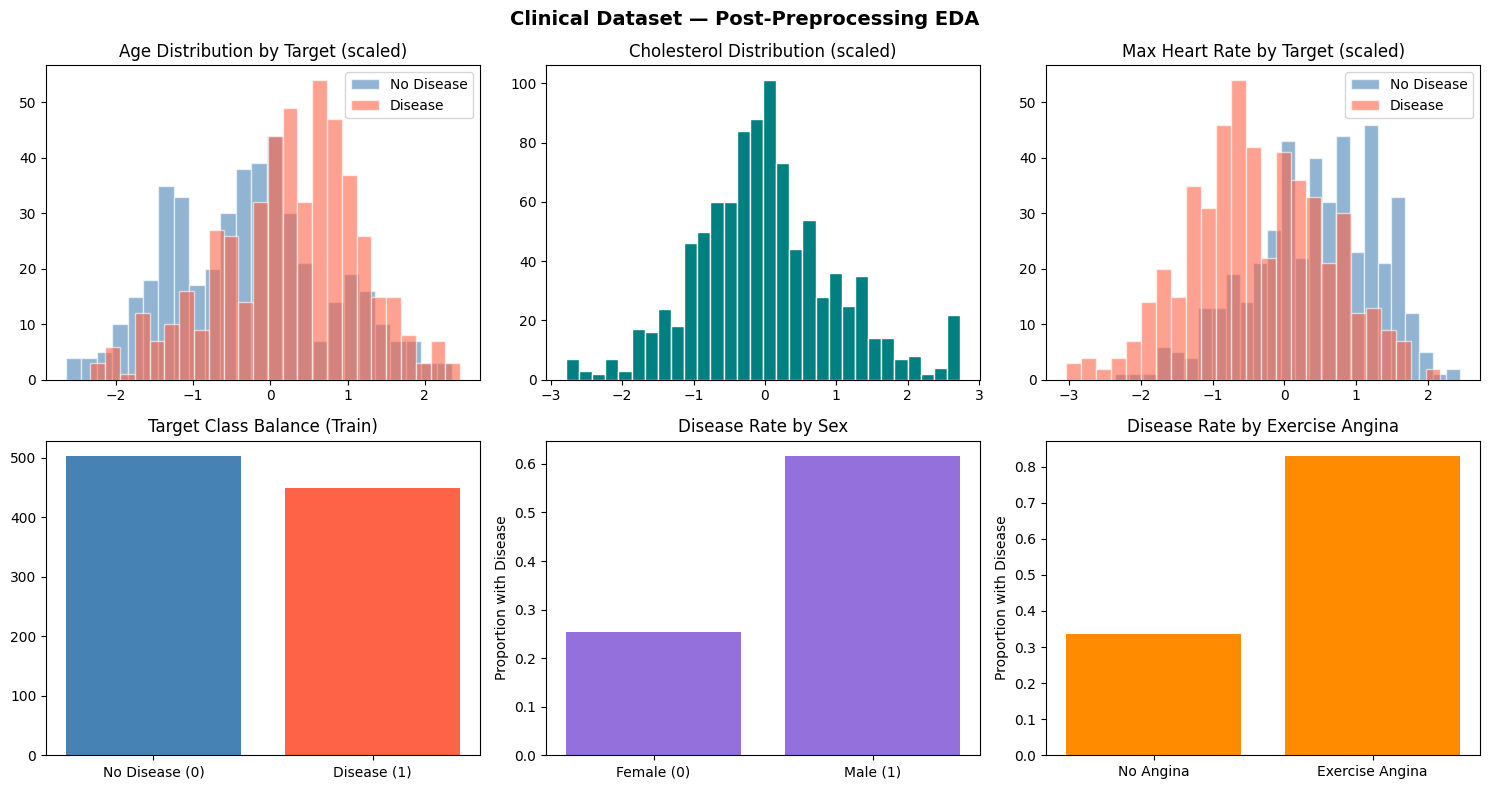


  ✅ EDA plot saved to: /content/drive/MyDrive/CAD_DT_Final/Outputs/Figures/clinical_eda.png


In [18]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Clinical Dataset — Post-Preprocessing EDA', fontsize=14, fontweight='bold')

# 1. Age distribution by target
for t, label, color in [(0, 'No Disease', 'steelblue'), (1, 'Disease', 'tomato')]:
    subset = df_train_out[df_train_out['target'] == t]['age']
    axes[0,0].hist(subset, bins=25, alpha=0.6, label=label, color=color, edgecolor='white')
axes[0,0].set_title('Age Distribution by Target (scaled)')
axes[0,0].legend()

# 2. Cholesterol distribution
axes[0,1].hist(df_train_out['cholesterol'], bins=30, color='teal', edgecolor='white')
axes[0,1].set_title('Cholesterol Distribution (scaled)')

# 3. Max Heart Rate vs target
for t, label, color in [(0, 'No Disease', 'steelblue'), (1, 'Disease', 'tomato')]:
    subset = df_train_out[df_train_out['target'] == t]['max_heart_rate']
    axes[0,2].hist(subset, bins=25, alpha=0.6, label=label, color=color, edgecolor='white')
axes[0,2].set_title('Max Heart Rate by Target (scaled)')
axes[0,2].legend()

# 4. Target balance
tc = df_train_out['target'].value_counts()
axes[1,0].bar(['No Disease (0)', 'Disease (1)'], tc.values, color=['steelblue','tomato'])
axes[1,0].set_title('Target Class Balance (Train)')

# 5. Sex vs target
sex_target = df_train_out.groupby('sex')['target'].mean()
axes[1,1].bar(['Female (0)', 'Male (1)'], sex_target.values, color='mediumpurple')
axes[1,1].set_title('Disease Rate by Sex')
axes[1,1].set_ylabel('Proportion with Disease')

# 6. Exercise Angina vs target
ea_target = df_train_out.groupby('exercise_angina')['target'].mean()
axes[1,2].bar(['No Angina', 'Exercise Angina'], ea_target.values, color='darkorange')
axes[1,2].set_title('Disease Rate by Exercise Angina')
axes[1,2].set_ylabel('Proportion with Disease')
plt.tight_layout()

plt.savefig(EDA_FIG_PATH, dpi=150, bbox_inches='tight')
plt.show()

print(f"\n  ✅ EDA plot saved to: {EDA_FIG_PATH}")


---
## Section 13 — Final Pipeline Validation

This cell runs a comprehensive set of assertions to confirm the pipeline produced correct outputs.

### ⚠️ Why raw test and processed test have different column counts — this is expected

| File | Columns | Reason |
|---|---|---|
| `df_clinical_test_raw.csv` | 12 | Pre-processing snapshot: 11 features + target |
| `df_clinical_test.csv` | 19 | Post-OHE: 18 features + target |

One-hot encoding expands 3 categorical columns into 9 dummies (+7 net new columns).  
The raw file is saved for interpretability and auditing — it is **not** used for model training.

### Checks performed
1. **Row counts** — train + test rows = total dataset rows
2. **Column expansion** — processed test has more columns than raw (OHE confirmed)
3. **NaN check** — no missing values in any processed output
4. **Class balance** — train/test positive rates within 5% of each other
5. **Dtype check** — target is integer, float cols are continuous features
6. **Feature integrity** — `ca` and `thal` are correctly absent
7. **Leakage check** — IQR bounds, imputer, and scaler all fitted on X_train only


In [19]:
# ── Section 13 — Final Pipeline Validation ───────────────────────────────────
print("=" * 65)
print("PIPELINE VALIDATION — FINAL CHECKS")
print("=" * 65)

# ── [1] Row count check ───────────────────────────────────────────────────────
print("\n[1] Row count check")
n_train = df_train_out.shape[0]
n_test  = df_test_out.shape[0]
n_total = len(df)
print(f"    df_clinical_train rows    : {n_train}")
print(f"    df_clinical_test rows     : {n_test}")
print(f"    Total dataset rows        : {n_total}")
print(f"    train + test              : {n_train + n_test}")
assert n_train + n_test == n_total, \
    f"Row count mismatch! {n_train} + {n_test} = {n_train+n_test} ≠ {n_total}"
assert df_clinical_test_raw.shape[0] == n_test, \
    f"Raw test row count mismatch: {df_clinical_test_raw.shape[0]} ≠ {n_test}"
print("    ✅ Row counts consistent")

# ── [2] Column expansion check (OHE) ─────────────────────────────────────────
# NOTE: raw test (12 cols) vs processed test (19 cols) is EXPECTED — not a bug.
# One-hot encoding expands chest_pain_type (4 cats), resting_ecg (3 cats),
# st_slope (3 cats) → removes 3 original cols, adds 10 dummies = net +7 cols.
print("\n[2] Column expansion check (One-Hot Encoding)")
raw_cols       = df_clinical_test_raw.shape[1]
processed_cols = df_test_out.shape[1]
print(f"    df_clinical_test_raw cols : {raw_cols}   (pre-OHE: 11 features + target)")
print(f"    df_clinical_test cols     : {processed_cols}  (post-OHE: 18 features + target)")
assert processed_cols > raw_cols, \
    f"Processed test should have MORE columns than raw after OHE, got {processed_cols} vs {raw_cols}"
assert df_train_out.shape[1] == df_test_out.shape[1], \
    f"Train and processed test must have same columns! {df_train_out.shape[1]} ≠ {df_test_out.shape[1]}"
print(f"    Column expansion: {raw_cols} → {processed_cols} (+{processed_cols - raw_cols} from OHE) ✅")
print(f"    Train and test have identical columns ({df_train_out.shape[1]}) ✅")

# ── [3] NaN check ────────────────────────────────────────────────────────────
print("\n[3] NaN check")
train_nans = df_train_out.isnull().sum().sum()
test_nans  = df_test_out.isnull().sum().sum()
print(f"    NaN in df_clinical_train  : {train_nans}")
print(f"    NaN in df_clinical_test   : {test_nans}")
assert train_nans == 0, f"NaN found in train output! ({train_nans})"
assert test_nans  == 0, f"NaN found in test output! ({test_nans})"
print("    ✅ No NaN values in any processed output")

# ── [4] Class balance check ───────────────────────────────────────────────────
print("\n[4] Class balance (stratification check)")
train_pos = df_train_out['target'].mean()
test_pos  = df_test_out['target'].mean()
diff      = abs(train_pos - test_pos)
print(f"    Train positive rate : {train_pos:.4f}  ({df_train_out['target'].sum()} / {n_train})")
print(f"    Test  positive rate : {test_pos:.4f}  ({df_test_out['target'].sum()} / {n_test})")
print(f"    Absolute difference : {diff:.4f}")
assert diff < 0.05, f"Class balance too different: {train_pos:.3f} vs {test_pos:.3f} (diff={diff:.3f})"
print("    ✅ Stratification preserved (rate difference < 5%)")

# ── [5] Dtype check ───────────────────────────────────────────────────────────
print("\n[5] Dtype check")
target_dtype = df_train_out['target'].dtype
print(f"    target dtype (train) : {target_dtype}")
print(f"    target dtype (test)  : {df_test_out['target'].dtype}")
assert str(target_dtype).startswith('int'), \
    f"Target must be integer dtype, got {target_dtype}"
float_feats = [c for c in df_train_out.columns if df_train_out[c].dtype == float and c != 'target']
print(f"    Float feature cols   : {float_feats}")
print(f"    (these are the StandardScaler-transformed continuous features)")
print("    ✅ Dtypes correct")

# ── [6] Feature integrity — ca and thal must be absent ───────────────────────
print("\n[6] Invalid feature check")
for banned in ['ca', 'thal']:
    assert banned not in df_train_out.columns, \
        f"Column '{banned}' must NOT exist — it was intentionally omitted at source!"
    assert banned not in df_test_out.columns, \
        f"Column '{banned}' must NOT exist — it was intentionally omitted at source!"
print("    ✅ 'ca' and 'thal' correctly absent (>90% missing in source — excluded at merge)")

# ── [7] Leakage check ────────────────────────────────────────────────────────
print("\n[7] Leakage check")
# IQR bounds
assert 'iqr_bounds' in dir(), "iqr_bounds not found — was IQR clipping run?"
print(f"    IQR bounds computed from X_train for: {list(iqr_bounds.keys())}")
# Imputer
assert hasattr(imputer, 'n_iter_'), "Imputer not fitted on X_train!"
print(f"    MICE imputer fitted on X_train ({imputer.n_iter_} iterations)")
# Scaler
assert hasattr(scaler, 'mean_'), "Scaler not fitted on X_train!"
print(f"    Scaler fitted on X_train — learned means: {dict(zip(SCALE_COLS, scaler.mean_.round(2)))}")
print("    ✅ No leakage: all fit objects derived from X_train only")

# ── Summary ───────────────────────────────────────────────────────────────────
print()
print("=" * 65)
print("ALL VALIDATION CHECKS PASSED ✅")
print("=" * 65)
print(f"  Outputs written to: {CLINICAL_DIR}")
print()

print(f"  {'File':<40} {'Rows':>6}  {'Cols':>5}  Notes")
print(f"  {'-'*72}")

print(f"  {'df_clinical_train.csv':<40} {df_train_out.shape[0]:>6}  {df_train_out.shape[1]:>5}  scaled + encoded")
print(f"  {'df_clinical_test.csv':<40} {df_test_out.shape[0]:>6}  {df_test_out.shape[1]:>5}  scaled + encoded")
print(f"  {'df_clinical_test_raw.csv':<40} {df_clinical_test_raw.shape[0]:>6}  {df_clinical_test_raw.shape[1]:>5}  pre-processing snapshot")
print(f"  {'clinical_imputer.pkl':<40}         MICE (fit on train only)")
print(f"  {'clinical_scaler.pkl':<40}         StandardScaler (fit on train only)")


PIPELINE VALIDATION — FINAL CHECKS

[1] Row count check
    df_clinical_train rows    : 952
    df_clinical_test rows     : 238
    Total dataset rows        : 1190
    train + test              : 1190
    ✅ Row counts consistent

[2] Column expansion check (One-Hot Encoding)
    df_clinical_test_raw cols : 12   (pre-OHE: 11 features + target)
    df_clinical_test cols     : 19  (post-OHE: 18 features + target)
    Column expansion: 12 → 19 (+7 from OHE) ✅
    Train and test have identical columns (19) ✅

[3] NaN check
    NaN in df_clinical_train  : 0
    NaN in df_clinical_test   : 0
    ✅ No NaN values in any processed output

[4] Class balance (stratification check)
    Train positive rate : 0.5284  (503 / 952)
    Test  positive rate : 0.5294  (126 / 238)
    Absolute difference : 0.0011
    ✅ Stratification preserved (rate difference < 5%)

[5] Dtype check
    target dtype (train) : int64
    target dtype (test)  : int64
    Float feature cols   : ['age', 'sex', 'resting_bp', 'ch